In [1]:
# ============================================================
# Cell 1 - Environment Setup
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib
from matplotlib import rcParams
from scipy import stats


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Matplotlib font settings
# ------------------------------------------------------------

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False


# ------------------------------------------------------------
# Global visualization settings
# ------------------------------------------------------------

rcParams.update({
    "figure.facecolor": "#1B2A4A",
    "axes.facecolor": "#243558",
    "axes.edgecolor": "#4A6080",
    "axes.labelcolor": "#FFFFFF",
    "axes.titlecolor": "#FFFFFF",
    "xtick.color": "#FFFFFF",
    "ytick.color": "#FFFFFF",
    "text.color": "#FFFFFF",
    "grid.color": "#4A6080",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor": "#4A6080",
    "legend.facecolor": "#1B2A4A",
})


# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------

BG_COLOR = "#1B2A4A"

C_GOOD = "#1D9E75"
C_BAD = "#C44E52"

C_BEFORE = "#4C72B0"
C_DURING = "#888780"
C_AFTER = "#C44E52"

In [2]:
# ============================================================
# Cell 2 - Data Loading
# ============================================================

DATA_DIR = Path("../data_collection")

raw_fin = pd.read_csv(
    DATA_DIR / "dart_earnings_financials_2019_2026.csv",
    dtype=str
)

raw_ctrl = pd.read_csv(
    DATA_DIR / "dart_financial_controls_2019_2025.csv"
)

raw_comp = pd.read_csv(
    DATA_DIR / "company_krx_fdr_controls_2019_2026.csv"
)

In [3]:
# ============================================================
# Cell 3 - Create df_hb (Same Procedure as Previous Notebooks)
# ============================================================

# ------------------------------------------------------------
# Filter out non-target reports
# ------------------------------------------------------------

remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly",
    na=False,
    regex=True
)

fin = raw_fin[~remove].copy()

fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()


# ------------------------------------------------------------
# Identify consolidated financial statements
# ------------------------------------------------------------

# "연결" is retained because it is a literal value
# contained in the original Korean report names.
fin["is_consolidated"] = fin["report_nm"].str.contains(
    "연결",
    na=False
)

fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)

fin = fin.drop_duplicates(
    subset=["stock_code", "rcept_dt"],
    keep="first"
)


# ------------------------------------------------------------
# Classify disclosure timing
# ------------------------------------------------------------

t = fin["rcept_time"].str.split(":", expand=True)

fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")

fin["timing"] = "Intraday"

fin.loc[
    fin["_h"] < 9,
    "timing"
] = "Pre-market"

fin.loc[
    (fin["_h"] > 15)
    | ((fin["_h"] == 15) & (fin["_m"] > 30)),
    "timing"
] = "After-hours"

fin.loc[
    fin["_h"].isna(),
    "timing"
] = None

fin.drop(
    columns=["_h", "_m"],
    inplace=True
)


# ------------------------------------------------------------
# Create date and weekday variables
# ------------------------------------------------------------

fin["rcept_dt_dt"] = pd.to_datetime(
    fin["rcept_dt"],
    format="%Y%m%d"
)

fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek


# ------------------------------------------------------------
# Calculate changes in operating income
# ------------------------------------------------------------

fin["oi_won"] = pd.to_numeric(
    fin["operating_income_won"],
    errors="coerce"
)

fin = fin.sort_values(
    ["stock_code", "rcept_dt_dt"]
)

fin["prev_oi"] = (
    fin.groupby("stock_code")["oi_won"]
    .shift(1)
)

fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna()
    & (fin["prev_oi"] != 0),

    (fin["oi_won"] - fin["prev_oi"])
    / fin["prev_oi"].abs(),

    np.nan
)


# ------------------------------------------------------------
# Classify news direction
# ------------------------------------------------------------

fin["news"] = np.select(
    [
        fin["oi_chg_pct"] > 0.10,
        fin["oi_chg_pct"] < -0.10,
        fin["oi_chg_pct"].between(
            -0.10,
            0.10,
            inclusive="both"
        )
    ],
    [
        "Good News",
        "Bad News",
        "Neutral"
    ],
    default="Missing"
)


# ------------------------------------------------------------
# Construct the final analysis sample
# ------------------------------------------------------------

df = fin.copy()

df_hb = df[
    df["news"].isin(["Good News", "Bad News"])
    & df["timing"].notna()
].copy()


# ------------------------------------------------------------
# Sample summary
# ------------------------------------------------------------

print(f"Final sample: {len(df):,} observations")

print(
    f"Good News: {df['news'].eq('Good News').sum():,}  "
    f"Bad News: {df['news'].eq('Bad News').sum():,}"
)

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030


## 11. Analysis of Additional Intraday Price Declines

## 11.1. Objective

This section examines whether additional intraday price adjustment occurs after the initial opening price gap following a disclosure.

In particular, the analysis tests whether bad news disclosed after market hours is associated not only with a negative opening price gap but also with additional downward price pressure during the subsequent trading session.

To examine this adjustment process, returns are decomposed into the following components:

- **Gap Return:** Return from the previous trading day's close to the next trading day's opening price
- **Intraday Return:** Return from the opening price to the closing price of the same trading day
- **Total Return:** Return from the previous trading day's close to the closing price of the next trading day

This decomposition allows us to examine whether the price impact of after-hours disclosures is largely incorporated at the market opening or whether additional price adjustment continues during the subsequent trading session.

---

In [4]:
# ============================================================
# Cell 4 - Load Stock Price Data
# ============================================================

price_df = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    dtype={"stock_code": str},
    low_memory=False
)

price_df["stock_code"] = price_df["stock_code"].astype(str).str.zfill(6)
price_df["date"] = pd.to_datetime(price_df["date"])
price_df["open"] = pd.to_numeric(price_df["open"], errors="coerce")
price_df["close"] = pd.to_numeric(price_df["close"], errors="coerce")

price_df = price_df.dropna(
    subset=["stock_code", "date", "open", "close"]
)

price_df = (
    price_df
    .sort_values(["stock_code", "date"])
    .reset_index(drop=True)
)

price_by_stock = {
    code: g.reset_index(drop=True)
    for code, g in price_df.groupby("stock_code")
}

print(f"Stock price data loaded: {price_df.shape}")

Stock price data loaded: (1657925, 8)


In [5]:
# ============================================================
# Cell 5 - Prepare Event Data
# ============================================================

intra_df = df_hb.copy()

intra_df = intra_df[
    intra_df["news"].isin(["Good News", "Bad News"])
    & intra_df["timing"].isin(["Pre-market", "Intraday", "After-hours"])
].copy()


# ------------------------------------------------------------
# Create event-level variables
# ------------------------------------------------------------

intra_df["stock_code"] = (
    intra_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

intra_df["rcept_dt_dt"] = pd.to_datetime(
    intra_df["rcept_dt"],
    format="%Y%m%d"
)

intra_df["after_dummy"] = (
    intra_df["timing"] == "After-hours"
).astype(int)

intra_df["bad_dummy"] = (
    intra_df["news"] == "Bad News"
).astype(int)

intra_df["fri_dummy"] = (
    intra_df["weekday"] == 4
).astype(int)


# ------------------------------------------------------------
# Merge market capitalization data
# ------------------------------------------------------------

intra_df = intra_df.merge(
    raw_comp[
        ["stock_code", "log_marcap"]
    ].drop_duplicates(subset="stock_code"),
    on="stock_code",
    how="left"
)


# ------------------------------------------------------------
# Classify firms into market-capitalization tertiles
# ------------------------------------------------------------

intra_df["size_group"] = pd.qcut(
    intra_df["log_marcap"],
    q=3,
    labels=["Small-cap", "Mid-cap", "Large-cap"]
)


# ------------------------------------------------------------
# Sample summary
# ------------------------------------------------------------

print(f"Event sample: {len(intra_df):,} observations")

Event sample: 8,551 observations


In [6]:
# ============================================================
# Cell 6 - Calculate Opening Gap and Intraday Returns
# ============================================================
# Gap Return      = (Next Open - Reference Close) / Reference Close
# Intraday Return = (Next Close - Next Open) / Next Open
# Total Return    = (Next Close - Reference Close) / Reference Close

def calc_returns(stock_code, event_date, after_dummy):
    stock_data = price_by_stock.get(stock_code)

    if stock_data is None or len(stock_data) < 2:
        return pd.Series({
            "gap_return": np.nan,
            "intra_return": np.nan,
            "total_return": np.nan
        })

    dates = stock_data["date"].values

    if after_dummy == 1:
        # After-hours disclosure:
        # Disclosure-day close → Next-day open → Next-day close
        idx = np.searchsorted(
            dates,
            np.datetime64(event_date),
            side="left"
        )

        if idx >= len(stock_data) - 1:
            return pd.Series({
                "gap_return": np.nan,
                "intra_return": np.nan,
                "total_return": np.nan
            })

        ref_close = stock_data.loc[idx, "close"]          # Disclosure-day close
        next_open = stock_data.loc[idx + 1, "open"]      # Next-day open
        next_close = stock_data.loc[idx + 1, "close"]    # Next-day close

    else:
        # Pre-market / Intraday disclosure:
        # Previous-day close → Disclosure-day open → Disclosure-day close
        idx = np.searchsorted(
            dates,
            np.datetime64(event_date),
            side="left"
        )

        if idx == 0 or idx >= len(stock_data):
            return pd.Series({
                "gap_return": np.nan,
                "intra_return": np.nan,
                "total_return": np.nan
            })

        ref_close = stock_data.loc[idx - 1, "close"]     # Previous-day close
        next_open = stock_data.loc[idx, "open"]          # Disclosure-day open
        next_close = stock_data.loc[idx, "close"]        # Disclosure-day close

    if any(
        pd.isna(v) or v <= 0
        for v in [ref_close, next_open, next_close]
    ):
        return pd.Series({
            "gap_return": np.nan,
            "intra_return": np.nan,
            "total_return": np.nan
        })

    gap_return = (
        (next_open - ref_close)
        / ref_close
    )

    intra_return = (
        (next_close - next_open)
        / next_open
    )

    total_return = (
        (next_close - ref_close)
        / ref_close
    )

    return pd.Series({
        "gap_return": gap_return,
        "intra_return": intra_return,
        "total_return": total_return
    })

In [7]:
# ============================================================
# Cell 7 - Calculate Returns
# ============================================================

print("Calculating returns...")

returns = intra_df.apply(
    lambda x: calc_returns(
        stock_code=x["stock_code"],
        event_date=x["rcept_dt_dt"],
        after_dummy=x["after_dummy"]
    ),
    axis=1
)

intra_df = pd.concat(
    [
        intra_df.reset_index(drop=True),
        returns.reset_index(drop=True)
    ],
    axis=1
)

# Remove observations with missing return values
intra_df = intra_df.dropna(
    subset=["gap_return", "intra_return", "total_return"]
).copy()


# ------------------------------------------------------------
# Winsorize returns at the 1st and 99th percentiles
# ------------------------------------------------------------

for col in ["gap_return", "intra_return", "total_return"]:
    lo = float(
        intra_df[col].quantile(0.01).iloc[0]
        if hasattr(intra_df[col].quantile(0.01), "iloc")
        else intra_df[col].quantile(0.01)
    )

    hi = float(
        intra_df[col].quantile(0.99).iloc[0]
        if hasattr(intra_df[col].quantile(0.99), "iloc")
        else intra_df[col].quantile(0.99)
    )

    intra_df[col] = intra_df[col].clip(
        lower=lo,
        upper=hi
    )


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print(f"Calculation complete: {len(intra_df):,} observations")

print("\n=== Summary Statistics ===")

print(
    intra_df[
        ["gap_return", "intra_return", "total_return"]
    ]
    .describe()
    .map(lambda x: f"{x * 100:.3f}%")
)

Calculating returns...
Calculation complete: 8,536 observations

=== Summary Statistics ===
        gap_return intra_return total_return
count  853600.000%  853600.000%  853600.000%
mean        0.216%       0.134%       0.370%
std         1.851%       3.876%       4.419%
min        -5.195%     -10.369%     -11.846%
25%        -0.611%      -1.950%      -1.937%
50%         0.000%       0.000%       0.000%
75%         0.891%       1.902%       2.347%
max         7.707%      13.838%      16.574%


## 11.2. Descriptive Statistics

Across the full sample of 8,536 observations, the mean gap return was **+0.216%**, the mean intraday return was **+0.134%**, and the mean total return was **+0.370%**.

The following analysis further examines how these return components vary across news types and disclosure timing categories.

In [8]:
# ============================================================
# Cell 8 - Mean Returns by News Type and Disclosure Timing
# ============================================================

group_ret = (
    intra_df
    .groupby(["news", "timing"])[
        ["gap_return", "intra_return", "total_return"]
    ]
    .mean()
    .reset_index()
)

# Convert returns to percentages
for col in ["gap_return", "intra_return", "total_return"]:
    group_ret[col] = group_ret[col] * 100


print("=== Return Decomposition by News Type and Disclosure Timing (%) ===")
print(
    group_ret
    .round(3)
    .to_string(index=False)
)

=== Return Decomposition by News Type and Disclosure Timing (%) ===
     news      timing  gap_return  intra_return  total_return
 Bad News After-hours      -0.548        -0.726        -1.268
 Bad News    Intraday       0.064        -0.499        -0.439
 Bad News  Pre-market      -0.062        -0.173        -0.217
Good News After-hours       1.121        -0.101         1.067
Good News    Intraday       0.161         1.450         1.641
Good News  Pre-market       1.332         0.340         1.673


### Return Decomposition by News Type and Disclosure Timing

| Disclosure Type | Gap Return | Intraday Return | Total Return |
|---|---:|---:|---:|
| Bad News - Pre-market | -0.062% | -0.173% | -0.217% |
| Bad News - Intraday | +0.064% | -0.499% | -0.439% |
| Bad News - After-hours | -0.548% | -0.726% | -1.268% |
| Good News - Pre-market | +1.332% | +0.340% | +1.673% |
| Good News - Intraday | +0.161% | +1.450% | +1.641% |
| Good News - After-hours | +1.121% | -0.101% | +1.067% |

Bad-news after-hours disclosures exhibit a negative opening price gap followed by an additional negative intraday return. The mean gap return is **-0.548%**, while the subsequent intraday return is **-0.726%**, resulting in a total return of **-1.268%**.

By contrast, bad-news intraday disclosures show only a limited opening price reaction (**+0.064%**) but a more pronounced negative return during the trading session (**-0.499%**), suggesting that much of the negative price adjustment occurs intraday.

For good-news disclosures, pre-market and after-hours announcements are associated primarily with positive opening price gaps (**+1.332%** and **+1.121%**, respectively). Good-news intraday disclosures, in contrast, exhibit a relatively small opening gap (**+0.161%**) followed by a substantially larger positive intraday return (**+1.450%**).

Overall, these patterns are consistent with differences in how price adjustment unfolds depending on when information is disclosed. Information released outside trading hours is reflected more strongly in opening prices, whereas information released during trading hours is associated with a greater share of price adjustment occurring within the trading session.

In [9]:
# ============================================================
# Cell 9 - T-Tests
# ============================================================


# ------------------------------------------------------------
# Check for duplicate columns
# ------------------------------------------------------------

print(intra_df.columns.tolist())
print(f"{intra_df.columns.duplicated().sum()} duplicate column(s)")


# ------------------------------------------------------------
# Remove duplicate columns
# ------------------------------------------------------------

intra_df = intra_df.loc[
    :,
    ~intra_df.columns.duplicated()
].copy()


# ------------------------------------------------------------
# Welch's t-test function
# ------------------------------------------------------------

def ttest_groups(df, col, mask1, mask2, label1, label2):

    g1 = df.loc[mask1, col]
    g2 = df.loc[mask2, col]

    t, p = stats.ttest_ind(
        g1.values,
        g2.values,
        equal_var=False,
        nan_policy="omit"
    )

    m1 = float(np.nanmean(g1.values))
    m2 = float(np.nanmean(g2.values))

    print(f"\n[{label1}] vs [{label2}]")

    print(
        f"  Mean: {m1 * 100:.3f}%  vs  "
        f"{m2 * 100:.3f}%"
    )

    print(
        f"  Difference: {(m1 - m2) * 100:+.3f}%p"
    )

    print(
        f"  t={float(t):.3f}, "
        f"p={float(p):.4f}  "
        f"{'★ Significant' if float(p) < 0.05 else 'Not significant'}"
    )


# ------------------------------------------------------------
# Key comparisons: Intraday Return
# ------------------------------------------------------------

print("=== Key Comparisons: Intraday Return ===")


# Bad News - After-hours vs. Bad News - Intraday
ttest_groups(
    intra_df,
    "intra_return",

    (
        (intra_df["news"] == "Bad News")
        & (intra_df["timing"] == "After-hours")
    ),

    (
        (intra_df["news"] == "Bad News")
        & (intra_df["timing"] == "Intraday")
    ),

    "Bad News - After-hours",
    "Bad News - Intraday"
)


# Bad News - After-hours vs. Good News - After-hours
ttest_groups(
    intra_df,
    "intra_return",

    (
        (intra_df["news"] == "Bad News")
        & (intra_df["timing"] == "After-hours")
    ),

    (
        (intra_df["news"] == "Good News")
        & (intra_df["timing"] == "After-hours")
    ),

    "Bad News - After-hours",
    "Good News - After-hours"
)


# ------------------------------------------------------------
# Key comparisons: Total Return
# ------------------------------------------------------------

print("\n=== Key Comparisons: Total Return ===")


# Bad News - After-hours vs. Bad News - Intraday
ttest_groups(
    intra_df,
    "total_return",

    (
        (intra_df["news"] == "Bad News")
        & (intra_df["timing"] == "After-hours")
    ),

    (
        (intra_df["news"] == "Bad News")
        & (intra_df["timing"] == "Intraday")
    ),

    "Bad News - After-hours",
    "Bad News - Intraday"
)

['corp_code', 'corp_name', 'stock_code', 'corp_cls', 'market', 'report_nm', 'rcept_no', 'flr_nm', 'rcept_dt', 'rm', 'rcept_time', 'sales', 'operating_income', 'net_income', 'amount_unit', 'sales_won', 'operating_income_won', 'net_income_won', 'status', 'reason', 'year', 'is_consolidated', 'timing', 'rcept_dt_dt', 'weekday', 'oi_won', 'prev_oi', 'oi_chg_pct', 'news', 'after_dummy', 'bad_dummy', 'fri_dummy', 'log_marcap', 'size_group', 'gap_return', 'intra_return', 'total_return']
0 duplicate column(s)
=== Key Comparisons: Intraday Return ===

[Bad News - After-hours] vs [Bad News - Intraday]
  Mean: -0.726%  vs  -0.499%
  Difference: -0.227%p
  t=-2.048, p=0.0407  ★ Significant

[Bad News - After-hours] vs [Good News - After-hours]
  Mean: -0.726%  vs  -0.101%
  Difference: -0.625%p
  t=-5.148, p=0.0000  ★ Significant

=== Key Comparisons: Total Return ===

[Bad News - After-hours] vs [Bad News - Intraday]
  Mean: -1.268%  vs  -0.439%
  Difference: -0.829%p
  t=-6.635, p=0.0000  ★ Signi

## 11.3. Tests for Additional Intraday Price Declines

### (1) Bad News - After-hours vs. Bad News - Intraday

Bad-news after-hours disclosures exhibit a significantly lower intraday return than bad-news intraday disclosures.

```text
Bad News - After-hours: -0.726%
Bad News - Intraday:    -0.499%
Difference:             -0.227%p

t = -2.047
p = 0.0407
```

The difference is statistically significant at the 5% level, indicating that bad-news after-hours disclosures are associated with a more negative intraday price adjustment following the market opening.

Combined with the negative opening price gap observed for this group, the result is consistent with additional downward price adjustment continuing during the subsequent trading session rather than being fully incorporated at the market opening.

---

### (2) Bad News - After-hours vs. Good News - After-hours

Compared with good-news after-hours disclosures, bad-news after-hours disclosures exhibit a substantially more negative intraday return.

```text
Bad News - After-hours:  -0.726%
Good News - After-hours: -0.101%
Difference:              -0.624%p

t = -5.147
p < 0.001
```

This difference is statistically significant, indicating that intraday price movements following after-hours disclosures differ substantially according to the direction of the disclosed information.

Bad-news after-hours disclosures are followed by a negative intraday return even after a negative opening gap. In contrast, good-news after-hours disclosures exhibit a strong positive opening gap but only a small negative intraday return, suggesting that a larger share of the positive price adjustment occurs at the market opening.

---

## 11.4. Total Return Analysis

Bad-news after-hours disclosures also exhibit a substantially more negative total return than bad-news intraday disclosures.

```text
Bad News - After-hours: -1.268%
Bad News - Intraday:    -0.439%
Difference:             -0.829%p

t = -6.634
p < 0.001
```

The difference is statistically significant, showing that bad-news after-hours disclosures are associated not only with a negative opening price gap but also with a substantially more negative price adjustment over the full trading horizon examined.

Taken together with the return decomposition results, the findings indicate that the negative price reaction associated with bad-news after-hours disclosures is not concentrated entirely at the market opening. Instead, the initial negative opening gap is followed by additional negative intraday adjustment, resulting in a larger overall decline.

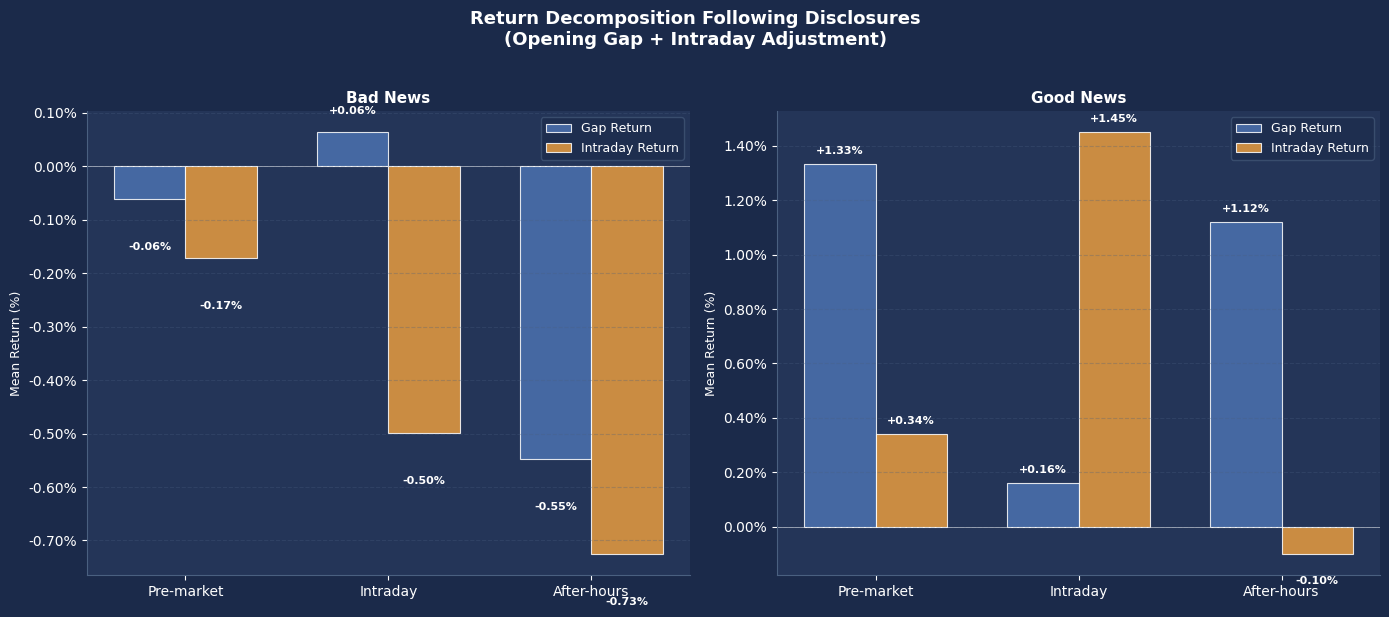

In [10]:
# ============================================================
# Cell 10 - Visualization 1: Return Decomposition Bar Chart
# ============================================================

# Remove duplicate columns if any remain
intra_df = intra_df.loc[:, ~intra_df.columns.duplicated()].copy()


# ------------------------------------------------------------
# Recalculate mean returns by news type and disclosure timing
# ------------------------------------------------------------

group_ret = (
    intra_df
    .groupby(["news", "timing"])[
        ["gap_return", "intra_return", "total_return"]
    ]
    .mean()
    .reset_index()
)

for col in ["gap_return", "intra_return", "total_return"]:
    group_ret[col] = group_ret[col] * 100


# ------------------------------------------------------------
# Create visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Return Decomposition Following Disclosures\n"
    "(Opening Gap + Intraday Adjustment)",
    fontsize=13,
    fontweight="bold",
    color="white",
    y=1.02
)


for ax, news in zip(
    axes,
    ["Bad News", "Good News"]
):

    ax.set_facecolor("#243558")

    sub = (
        group_ret[group_ret["news"] == news]
        .copy()
        .set_index("timing")
        .reindex(
            ["Pre-market", "Intraday", "After-hours"]
        )
    )

    x = np.arange(3)
    w = 0.35

    gap_vals = (
        sub["gap_return"]
        .values
        .astype(float)
    )

    intra_vals = (
        sub["intra_return"]
        .values
        .astype(float)
    )


    # Gap returns
    bars_gap = ax.bar(
        x - w / 2,
        gap_vals,
        w,
        label="Gap Return",
        color="#4C72B0",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8
    )


    # Intraday returns
    bars_intra = ax.bar(
        x + w / 2,
        intra_vals,
        w,
        label="Intraday Return",
        color="#E89C3F",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.8
    )


    # Value labels
    for bar in list(bars_gap) + list(bars_intra):

        val = bar.get_height()

        if abs(val) > 0.02:

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + (
                    0.03
                    if val >= 0
                    else -0.08
                ),
                f"{val:+.2f}%",
                ha="center",
                va=(
                    "bottom"
                    if val >= 0
                    else "top"
                ),
                fontsize=8,
                color="white",
                fontweight="bold"
            )


    # Axis formatting
    ax.axhline(
        0,
        color="white",
        linewidth=0.7,
        alpha=0.5
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        ["Pre-market", "Intraday", "After-hours"]
    )

    ax.set_title(
        news,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Mean Return (%)",
        fontsize=9
    )

    ax.yaxis.set_major_formatter(
        mtick.FormatStrFormatter("%.2f%%")
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    ax.spines[
        ["left", "bottom"]
    ].set_color("#4A6080")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color="#4A6080"
    )

    ax.legend(
        fontsize=9
    )


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "11_1_return_decomposition.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

## 11.4.1. Interpretation of the Return Decomposition

The return decomposition shows distinct patterns in opening price gaps and subsequent intraday returns across disclosure timing categories.

For bad-news disclosures, after-hours announcements exhibit the most negative return pattern.

| Disclosure Type | Gap Return | Intraday Return |
|---|---:|---:|
| Bad News - Pre-market | -0.06% | -0.17% |
| Bad News - Intraday | +0.06% | -0.50% |
| Bad News - After-hours | -0.55% | -0.73% |

Bad-news after-hours disclosures exhibit a substantial negative opening gap followed by an additional negative intraday return. Despite an initial gap return of **-0.55%**, prices decline by a further **-0.73%** during the subsequent trading session.

This pattern indicates that the negative price adjustment associated with bad-news after-hours disclosures is not concentrated entirely at the market opening. Instead, additional downward adjustment continues during the trading session.

By contrast, bad-news intraday disclosures exhibit almost no opening gap (**+0.06%**) but a considerably more negative intraday return (**-0.50%**). This pattern is consistent with a larger share of the price adjustment occurring during trading hours when the information is disclosed intraday.

---

Good-news disclosures exhibit a different pattern.

| Disclosure Type | Gap Return | Intraday Return |
|---|---:|---:|
| Good News - Pre-market | +1.33% | +0.34% |
| Good News - Intraday | +0.16% | +1.45% |
| Good News - After-hours | +1.12% | -0.10% |

For good news released outside trading hours, a larger share of the positive price reaction appears in the opening gap.

Good-news after-hours disclosures, in particular, exhibit a substantial positive opening gap of **+1.12%**, followed by a small negative intraday return of **-0.10%**. This pattern suggests that much of the positive price adjustment associated with these disclosures occurs by the market opening, with little additional upward adjustment during the subsequent trading session.

Good-news intraday disclosures show the opposite pattern: the opening gap is relatively small (**+0.16%**), while the intraday return reaches **+1.45%**. This is consistent with a larger share of the positive price adjustment occurring during the trading session when good news is disclosed intraday.

---

Overall, the results reveal different patterns in the timing of price adjustment across disclosure categories.

**Bad News - After-hours:**

- Negative opening price gap
- Additional negative intraday return
- Larger negative total return

**Good News - After-hours:**

- Substantial positive opening price gap
- Little additional positive intraday adjustment

These patterns indicate an asymmetry in the post-disclosure return decomposition. Bad-news after-hours disclosures are associated with negative price adjustment both at the market opening and during the subsequent trading session, whereas the positive reaction to good-news after-hours disclosures is concentrated primarily in the opening gap.

Taken together, the findings suggest that the negative price reaction associated with bad-news after-hours disclosures is not fully concentrated at the next market opening. Instead, it is followed by additional negative intraday adjustment, contributing to a larger negative total return over the full trading horizon examined.

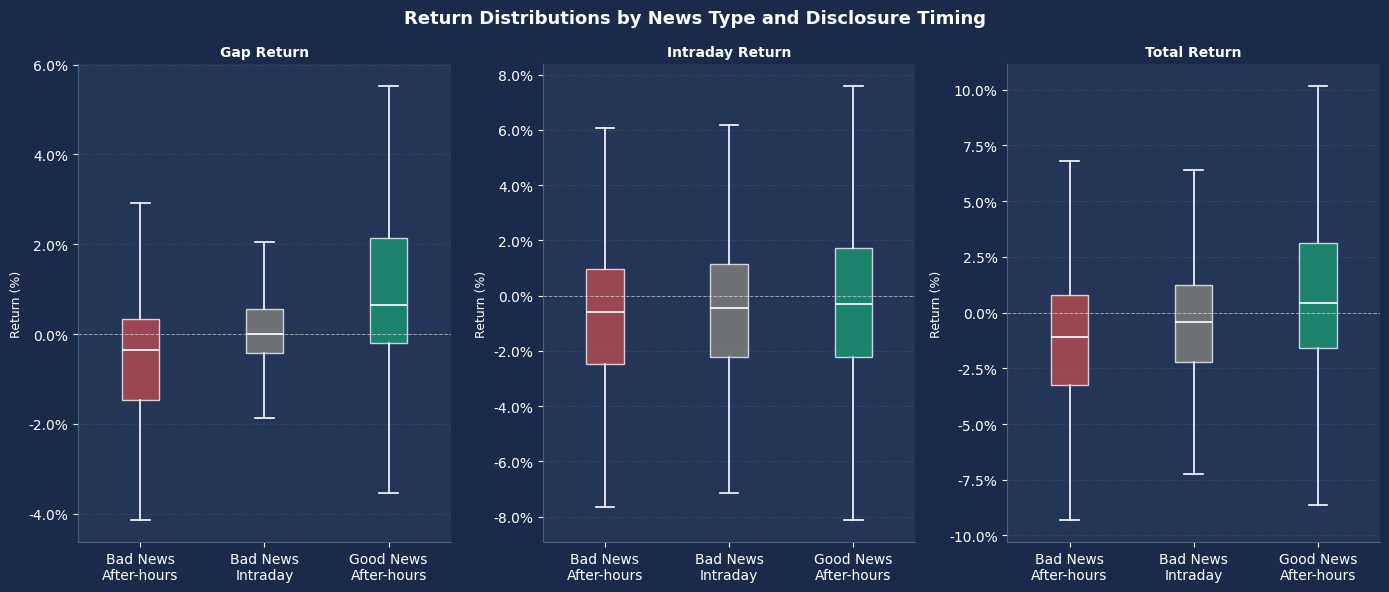


Saved figures:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\11_1_return_decomposition.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\11_2_return_boxplot.png


In [11]:
# ============================================================
# Cell 11 - Visualization 2: Return Distribution Boxplots
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 6)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Return Distributions by News Type and Disclosure Timing",
    fontsize=13,
    fontweight="bold",
    color="white"
)


# ------------------------------------------------------------
# Return measures
# ------------------------------------------------------------

titles = [
    "Gap Return",
    "Intraday Return",
    "Total Return"
]

cols = [
    "gap_return",
    "intra_return",
    "total_return"
]


# ------------------------------------------------------------
# Define comparison groups
# ------------------------------------------------------------

mask_bad_after = (
    (intra_df["news"] == "Bad News")
    & (intra_df["timing"] == "After-hours")
)

mask_bad_during = (
    (intra_df["news"] == "Bad News")
    & (intra_df["timing"] == "Intraday")
)

mask_good_after = (
    (intra_df["news"] == "Good News")
    & (intra_df["timing"] == "After-hours")
)


# ------------------------------------------------------------
# Create boxplots
# ------------------------------------------------------------

for ax, title, col in zip(axes, titles, cols):

    ax.set_facecolor("#243558")

    plot_data = [
        intra_df.loc[mask_bad_after, col] * 100,
        intra_df.loc[mask_bad_during, col] * 100,
        intra_df.loc[mask_good_after, col] * 100,
    ]

    # Use tick_labels for recent Matplotlib versions
    box = ax.boxplot(
        plot_data,
        tick_labels=[
            "Bad News\nAfter-hours",
            "Bad News\nIntraday",
            "Good News\nAfter-hours"
        ],
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(
        box["boxes"],
        ["#C44E52", "#888780", "#1D9E75"]
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor("white")

    for element in ["whiskers", "caps", "medians"]:
        for item in box[element]:
            item.set_color("white")
            item.set_linewidth(1.2)

    ax.axhline(
        0,
        color="white",
        linewidth=0.7,
        alpha=0.5,
        linestyle="--"
    )

    ax.set_title(
        title,
        fontsize=10,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Return (%)",
        fontsize=9
    )

    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter()
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    ax.spines[
        ["left", "bottom"]
    ].set_color("#4A6080")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color="#4A6080"
    )


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "11_2_return_boxplot.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()


# ------------------------------------------------------------
# Output file paths
# ------------------------------------------------------------

print("\nSaved figures:")
print(OUTPUT_DIR / "11_1_return_decomposition.png")
print(OUTPUT_DIR / "11_2_return_boxplot.png")

## 11.5. Distributional Characteristics

The boxplot analysis reveals distinct distributional patterns for bad-news after-hours disclosures:

- The distribution of gap returns is shifted toward negative values.
- Intraday returns also show additional downward adjustment.
- Total returns exhibit the most negative distribution among the three comparison groups.

In particular, the total return distribution for bad-news after-hours disclosures shows substantial downside dispersion, indicating that some firms experience relatively large negative price movements.

By contrast, good-news after-hours disclosures exhibit a substantial positive opening gap but little additional upward adjustment during the subsequent trading session.

Taken together, these distributional patterns are consistent with an asymmetric price-adjustment process. For good-news after-hours disclosures, a substantial share of the positive reaction is concentrated at the market opening, whereas bad-news after-hours disclosures are associated with negative adjustment both at the opening and during the subsequent trading session.

---

## 11.6. Overall Interpretation

Overall, bad-news after-hours disclosures are associated not only with a negative opening price gap but also with additional negative price adjustment during the subsequent trading session.

The mean return decomposition shows a **-0.548% opening gap** followed by an additional **-0.726% intraday return**, resulting in a **-1.268% total return**. Moreover, the intraday return following bad-news after-hours disclosures is significantly more negative than that following bad-news intraday disclosures (**-0.726% vs. -0.499%, p = 0.0407**).

These findings indicate that the negative price reaction associated with bad-news after-hours disclosures is not concentrated entirely at the next market opening. Instead, additional downward adjustment continues during the trading session.

By contrast, good-news after-hours disclosures exhibit a substantial positive opening gap (**+1.121%**) followed by a small negative intraday return (**-0.101%**), suggesting that a larger share of the positive price adjustment is concentrated at the market opening.

Overall, the results reveal an asymmetric pattern in the timing of price adjustment following after-hours disclosures. Bad news is associated with negative adjustment both at the opening and during subsequent trading, whereas the positive reaction to good news is concentrated more heavily in the opening gap.

These findings provide evidence that bad-news after-hours disclosures are associated with continued downside price adjustment after the market opens. However, the analysis does not establish whether this pattern is caused by insufficient overnight information processing, differences in investor information access, or other market mechanisms.